In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats
import pickle

In [2]:
with open("../data/final_drugs_df","rb") as f:
    final_drugs_df =pickle.load(f)
with open("../data/final_indications_df","rb") as f:
    final_indications_df = pickle.load(f)
with open("../data/final_diseases_df","rb") as f:
    final_diseases_df =pickle.load(f)
with open("../data/final_trials_df","rb") as f:
    final_trials_df =pickle.load(f)

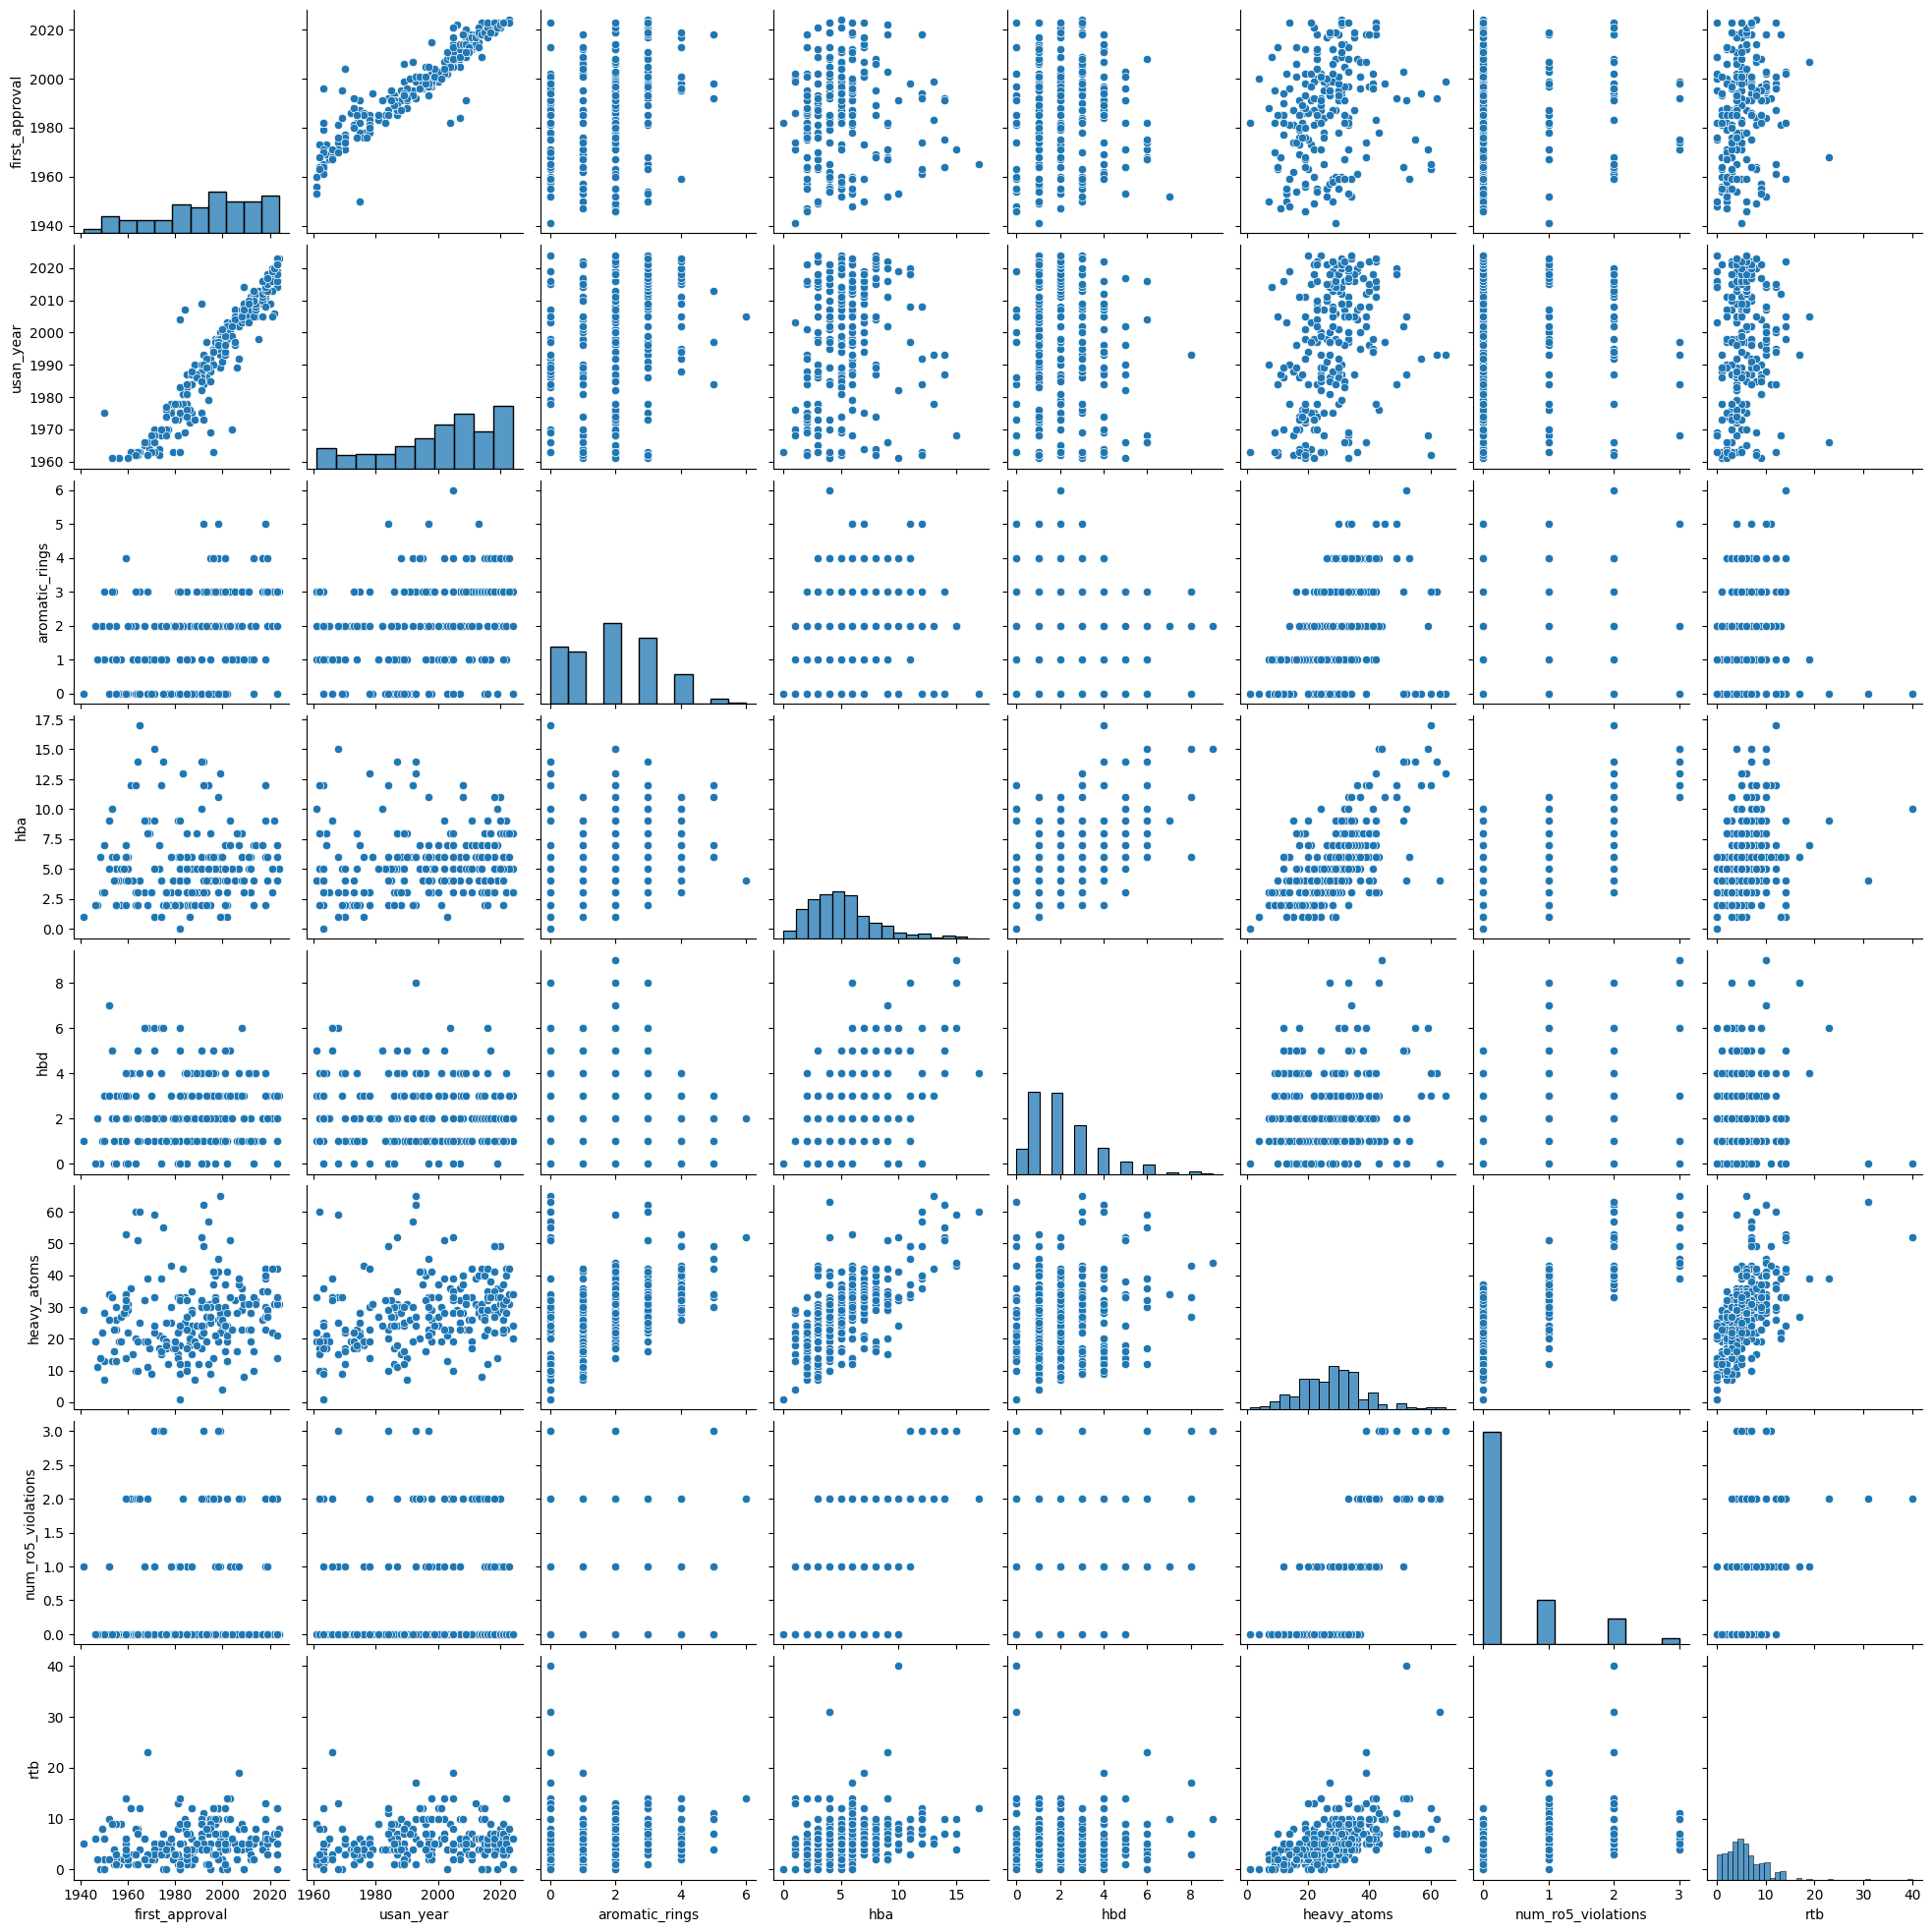

In [3]:
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
test = final_drugs_df.select_dtypes(include=numerics)
test = test.loc[:,test.apply(lambda col : len(pd.unique(col))>3)]
sns.pairplot(test, kind="scatter")

helm_notation           647
first_approval          335
psa                     293
aromatic_rings          293
hba                     293
hbd                     293
heavy_atoms             293
np_likeness_score       293
num_ro5_violations      293
alogp                   293
qed_weighted            293
ro3_pass                293
rtb                     293
usan_year               262
canonical_smiles        261
standard_inchi          261
standard_inchi_key      261
mw_freebase             259
full_mwt                259
full_molformula         259
targets                 254
usan_stem_definition    223
chirality                32
drug_name                 0
molecule_type             0
biotherapeutic            0
black_box_warning         0
chemical_probe            0
dosed_ingredient          0
first_in_class            0
inorganic_flag            0
max_phase                 0
natural_product           0
veterinary                0
oral                      0
orphan              

<Figure size 1000x600 with 0 Axes>

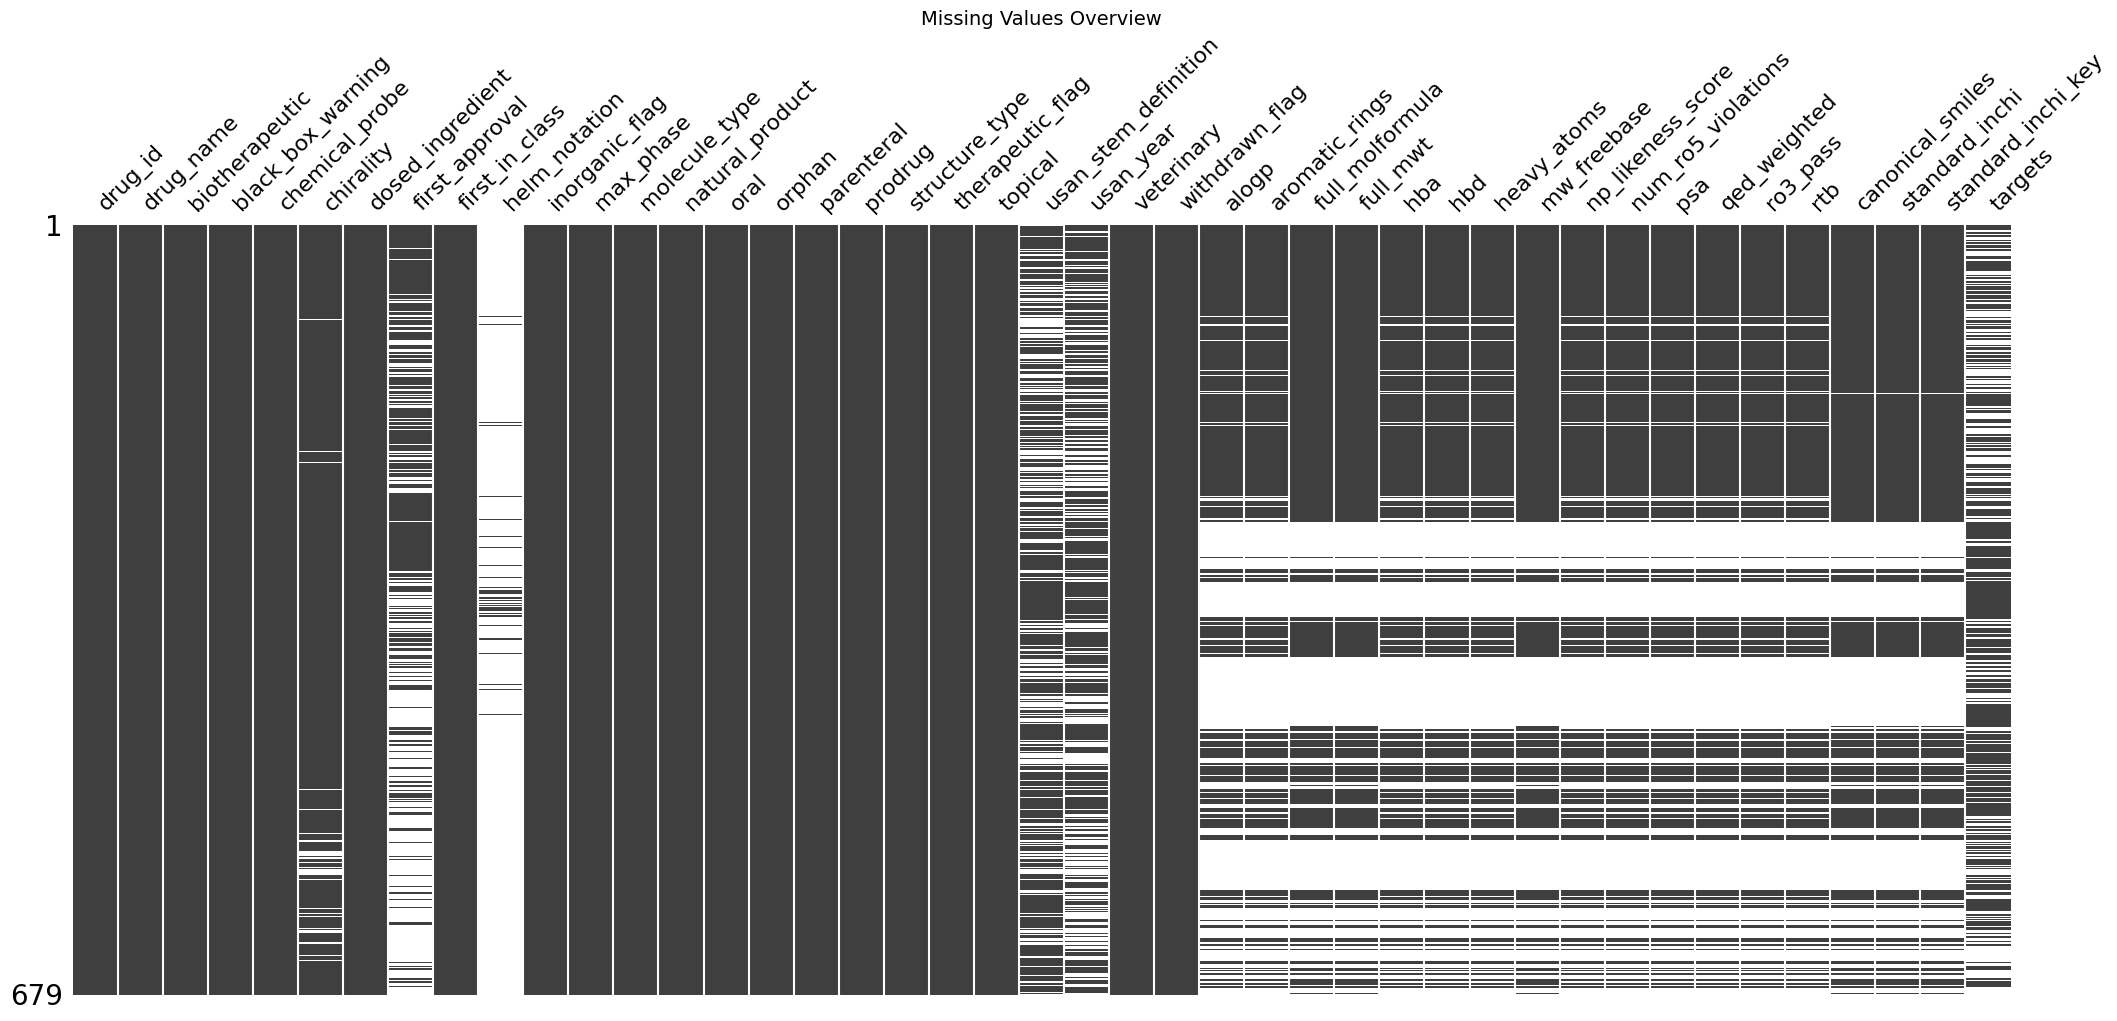

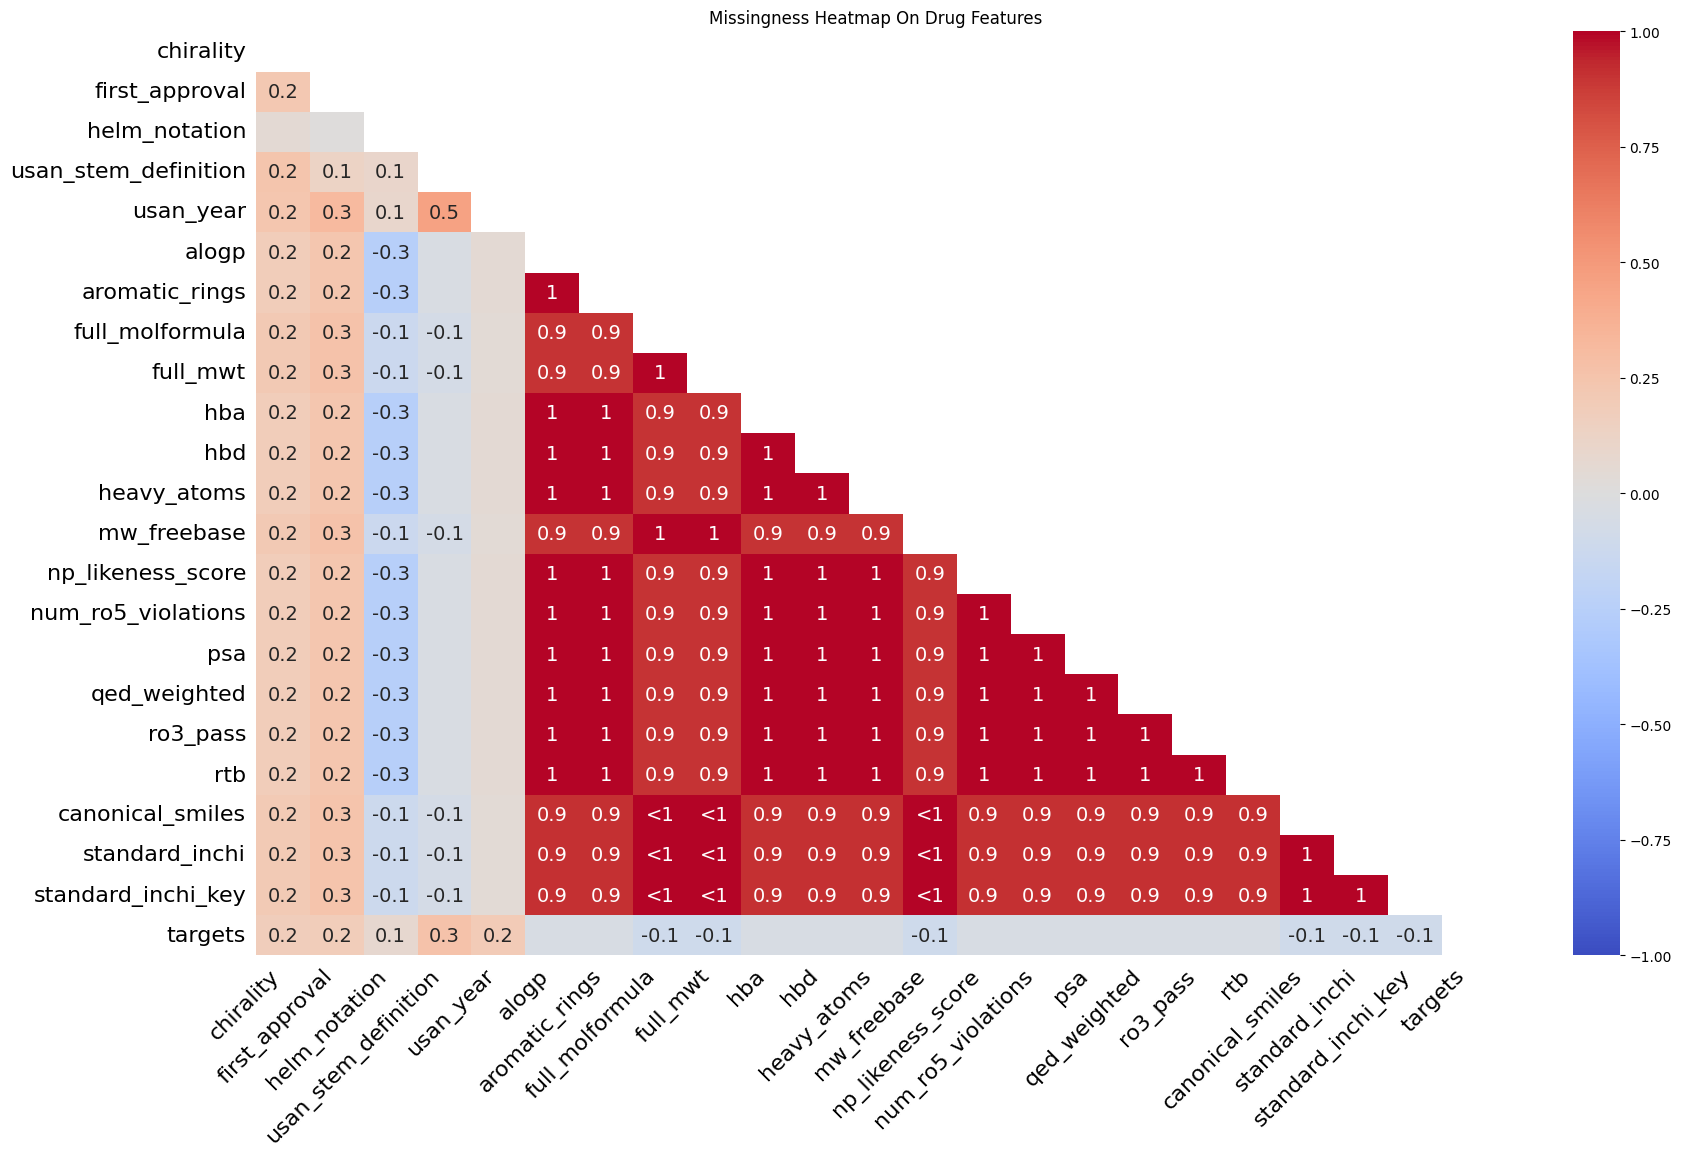

In [4]:
df = final_drugs_df
# Simple summary
print(df.isna().sum().sort_values(ascending=False))

# Visual overview
plt.figure(figsize=(10, 6))
msno.matrix(df, sparkline=False)
plt.title("Missing Values Overview", fontsize=14)
plt.show()

# Alternatively, a heatmap to see missing patterns
msno.heatmap(df, cmap="coolwarm")
plt.title("Missingness Heatmap On Drug Features")
plt.show()

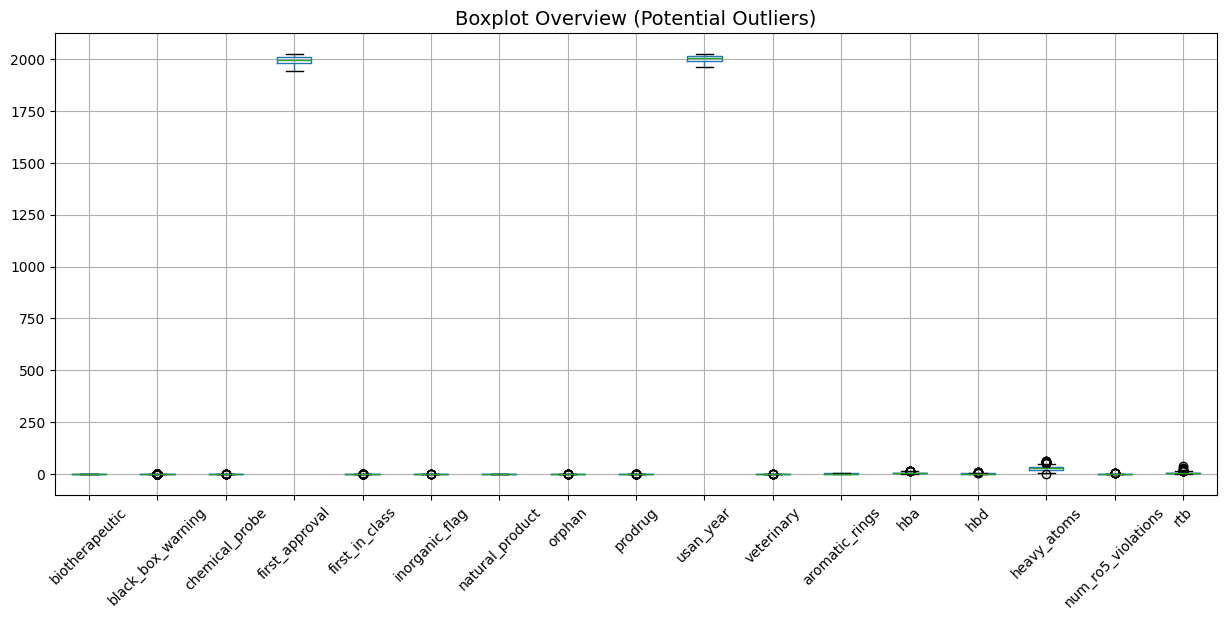

In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 6))
df[numeric_cols].boxplot(rot=45)
plt.title("Boxplot Overview (Potential Outliers)", fontsize=14)
plt.show()

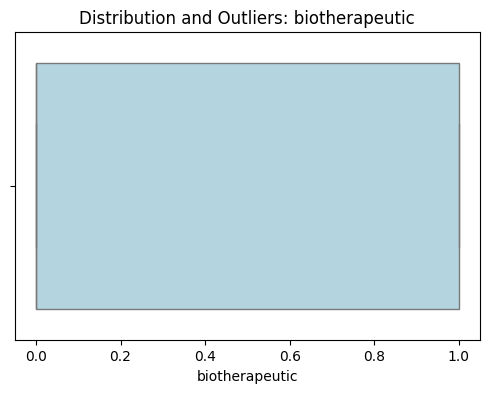

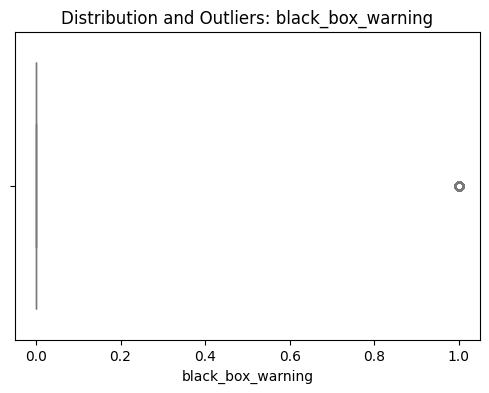

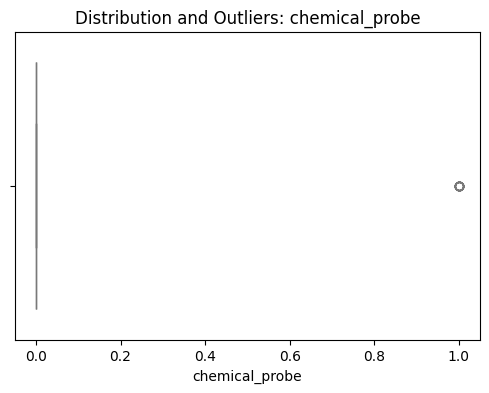

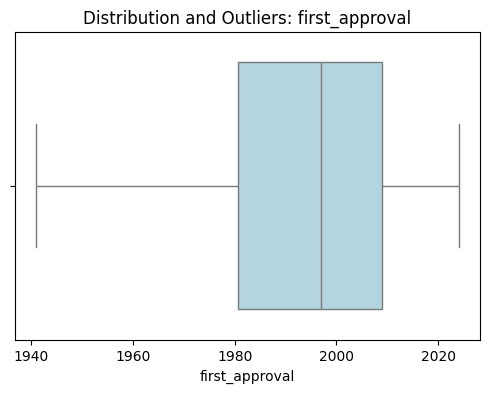

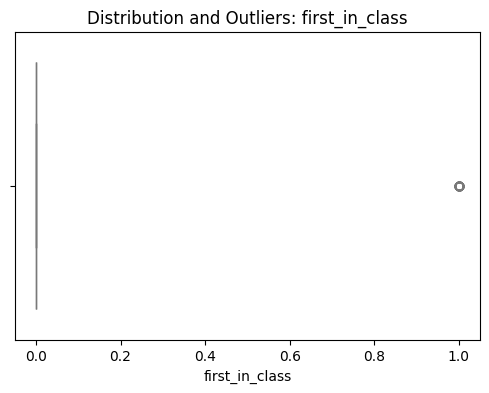

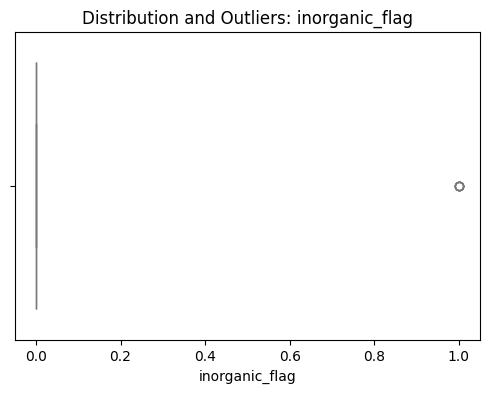

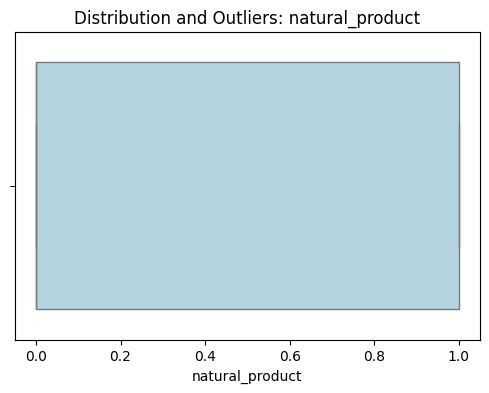

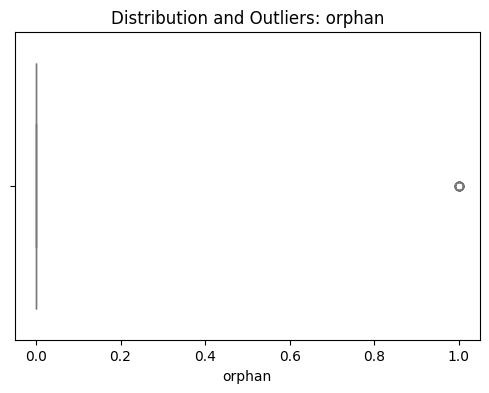

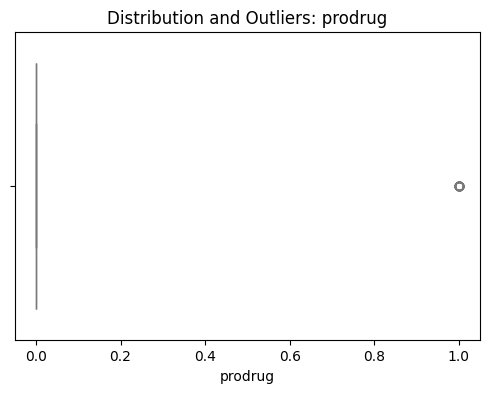

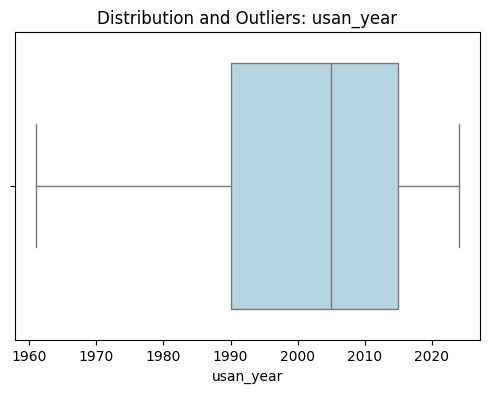

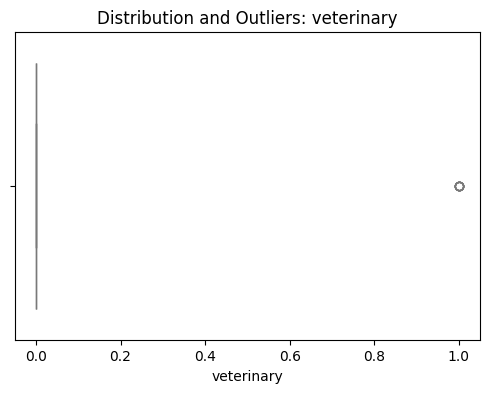

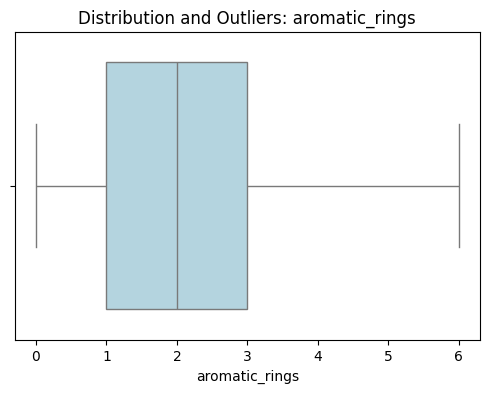

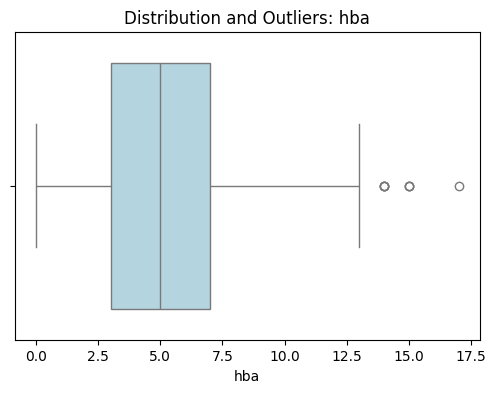

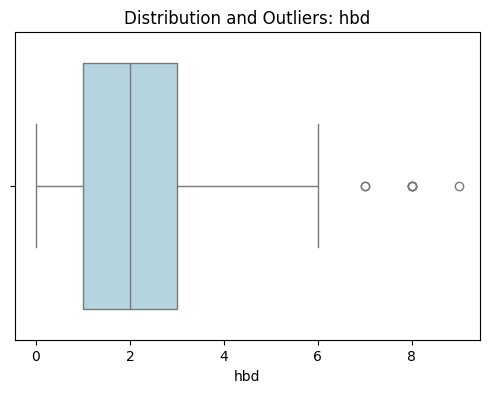

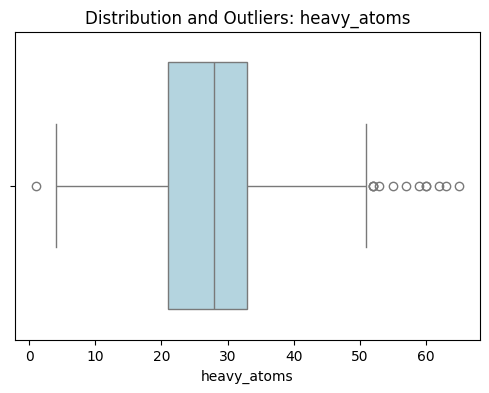

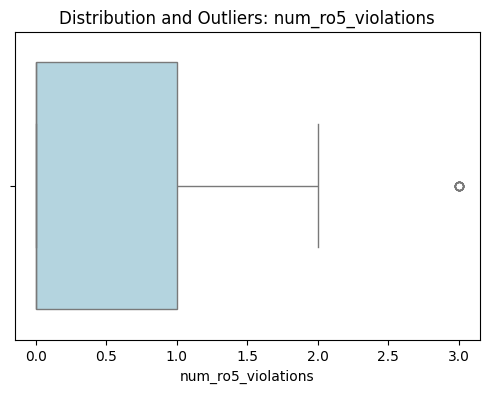

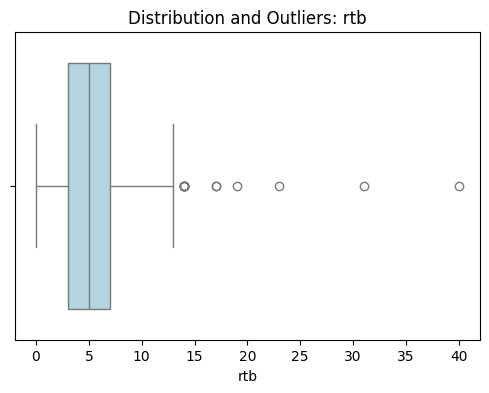

In [6]:
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color="lightblue")
    plt.title(f"Distribution and Outliers: {col}")
    plt.show()

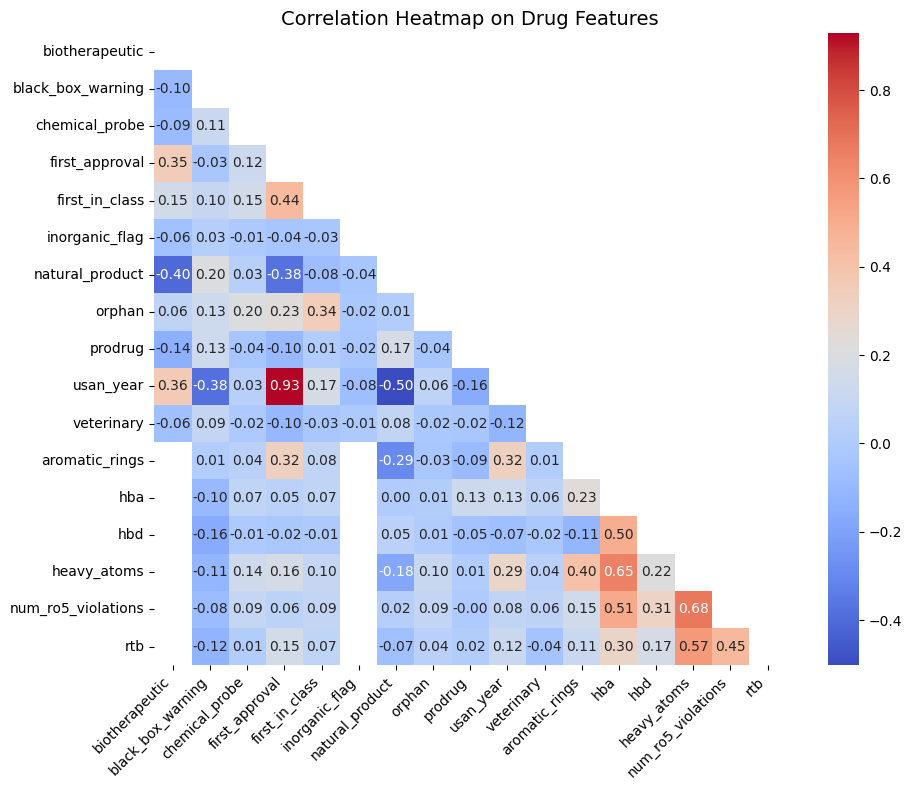

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[numeric_cols].corr()

# Mask lower triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.title("Correlation Heatmap on Drug Features", fontsize=14)
plt.tight_layout()
plt.show()

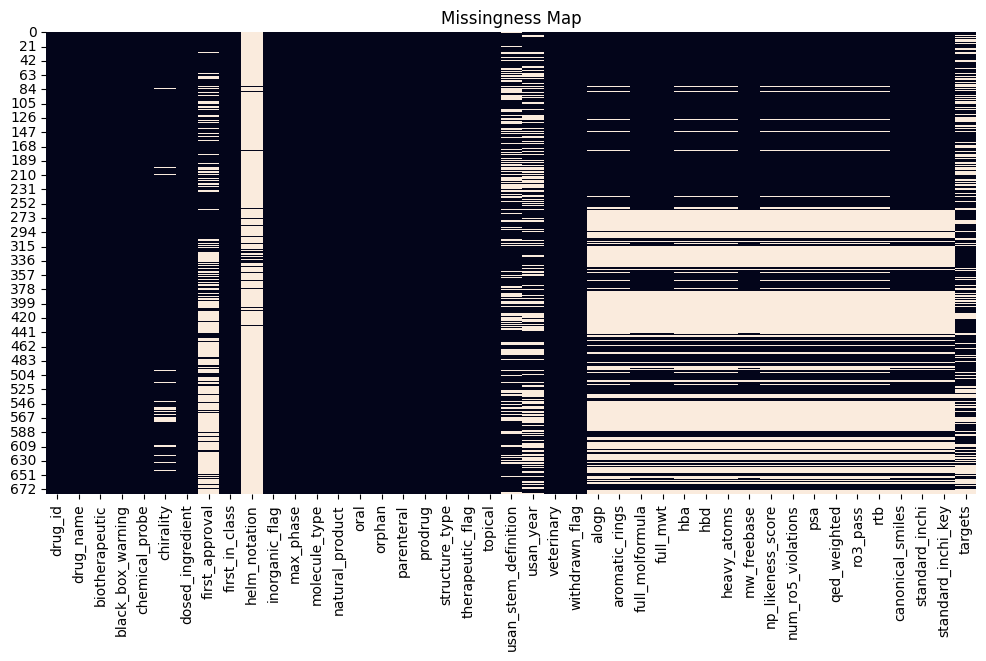

In [8]:
import numpy as np
plt.figure(figsize=(12,6))
sns.heatmap(df.isna(), cbar=False)  # missing values
plt.title("Missingness Map")
plt.show()

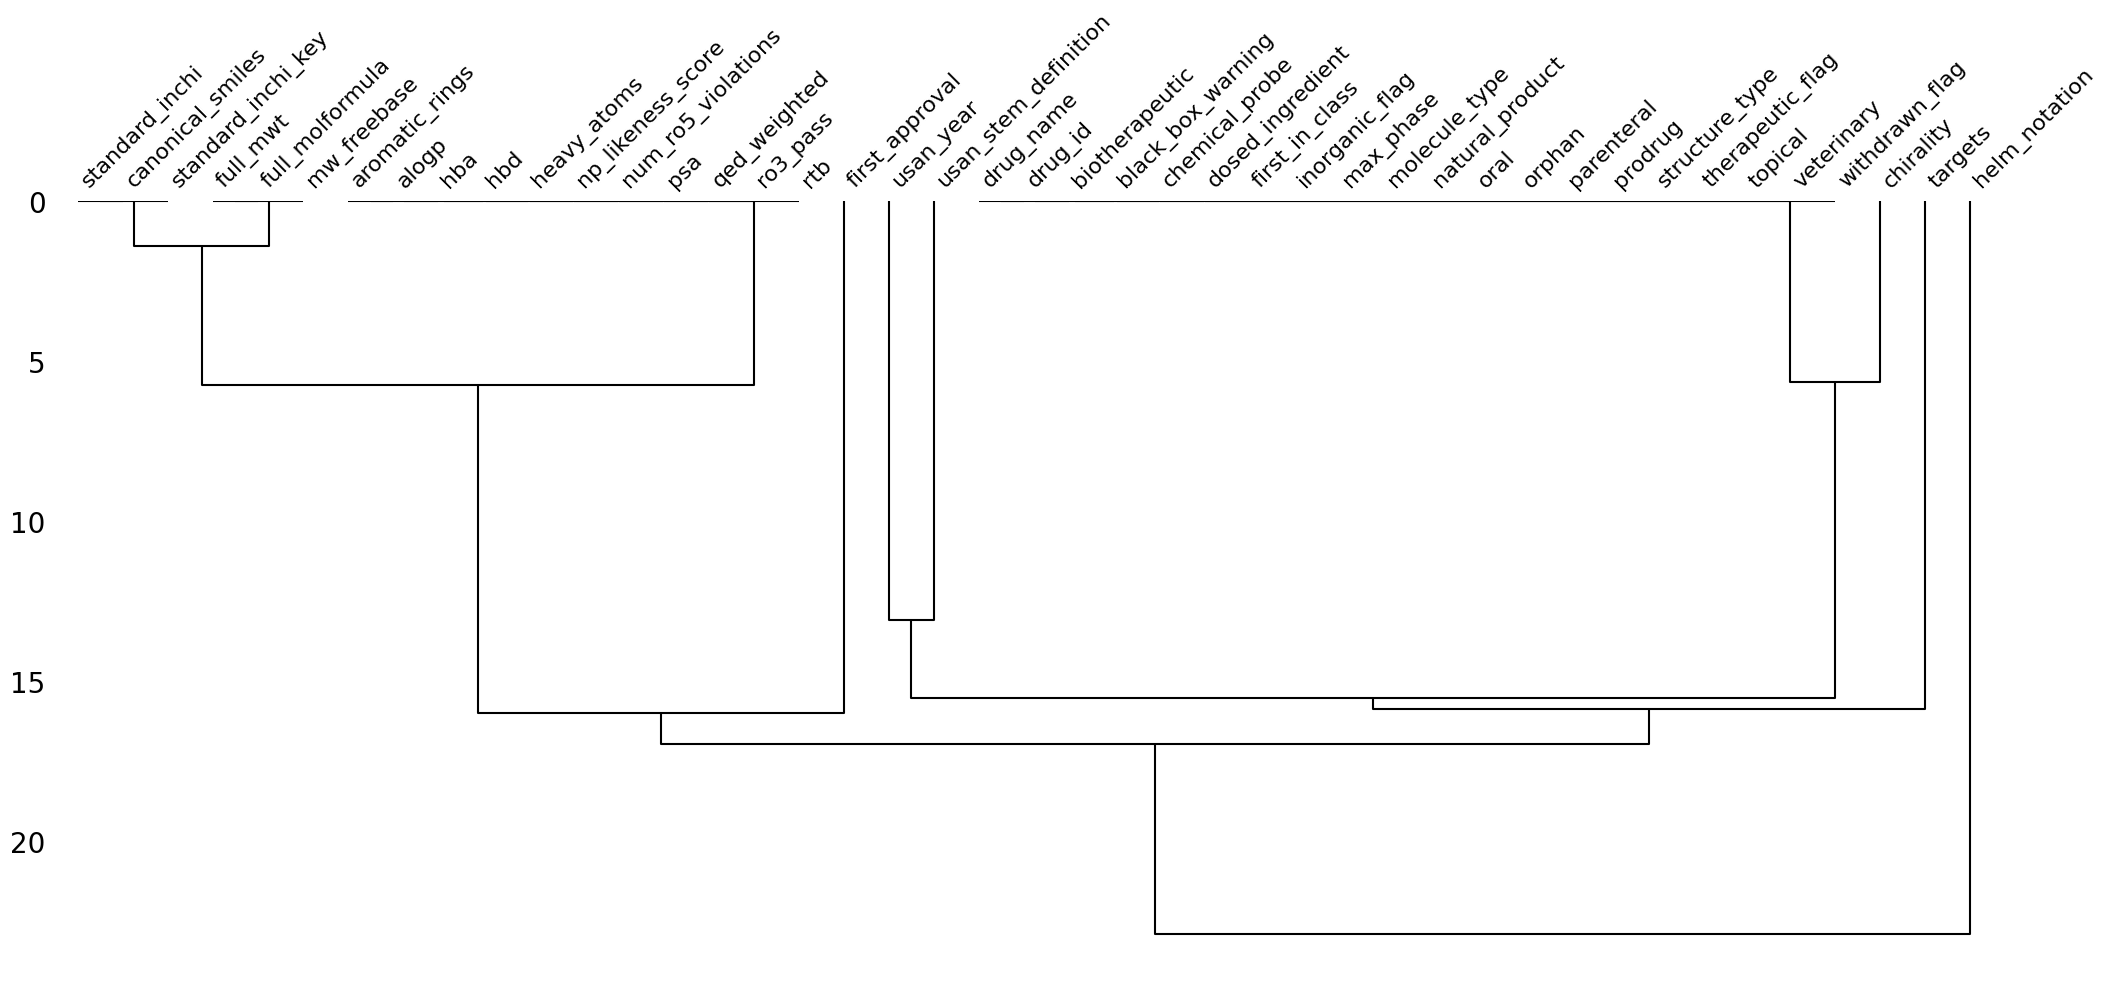

In [9]:
import missingno as msno
msno.dendrogram(df)
plt.show()

In [10]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='VariableA', y='VariableB', hue=df['VariableB'].isna())
plt.title("Scatter of VariableA vs VariableB (color shows missingness)")
plt.show()

KeyError: 'VariableB'

<Figure size 600x400 with 0 Axes>